In [1]:
# Adjust import path
import sys
sys.path.append("../ODEs")
sys.path.append("../")

In [2]:
# Imports
import os
import itertools
import math
import numpy as np
import matplotlib.pyplot as plt

import opinf

import utils
import config_lotka_volterra as config
import step1_generate_data as step1
import step1_5_estimate_priors as step1_5
import step2_fitgps as step2
import step3_estimate as step3
import step4_plot as step4
import torch
import numpy as np
import random

seed = 21092023  # Or any integer you prefer

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
%load_ext autoreload
%autoreload 2
import importlib
import sys

Logging to log.log


### Create Data

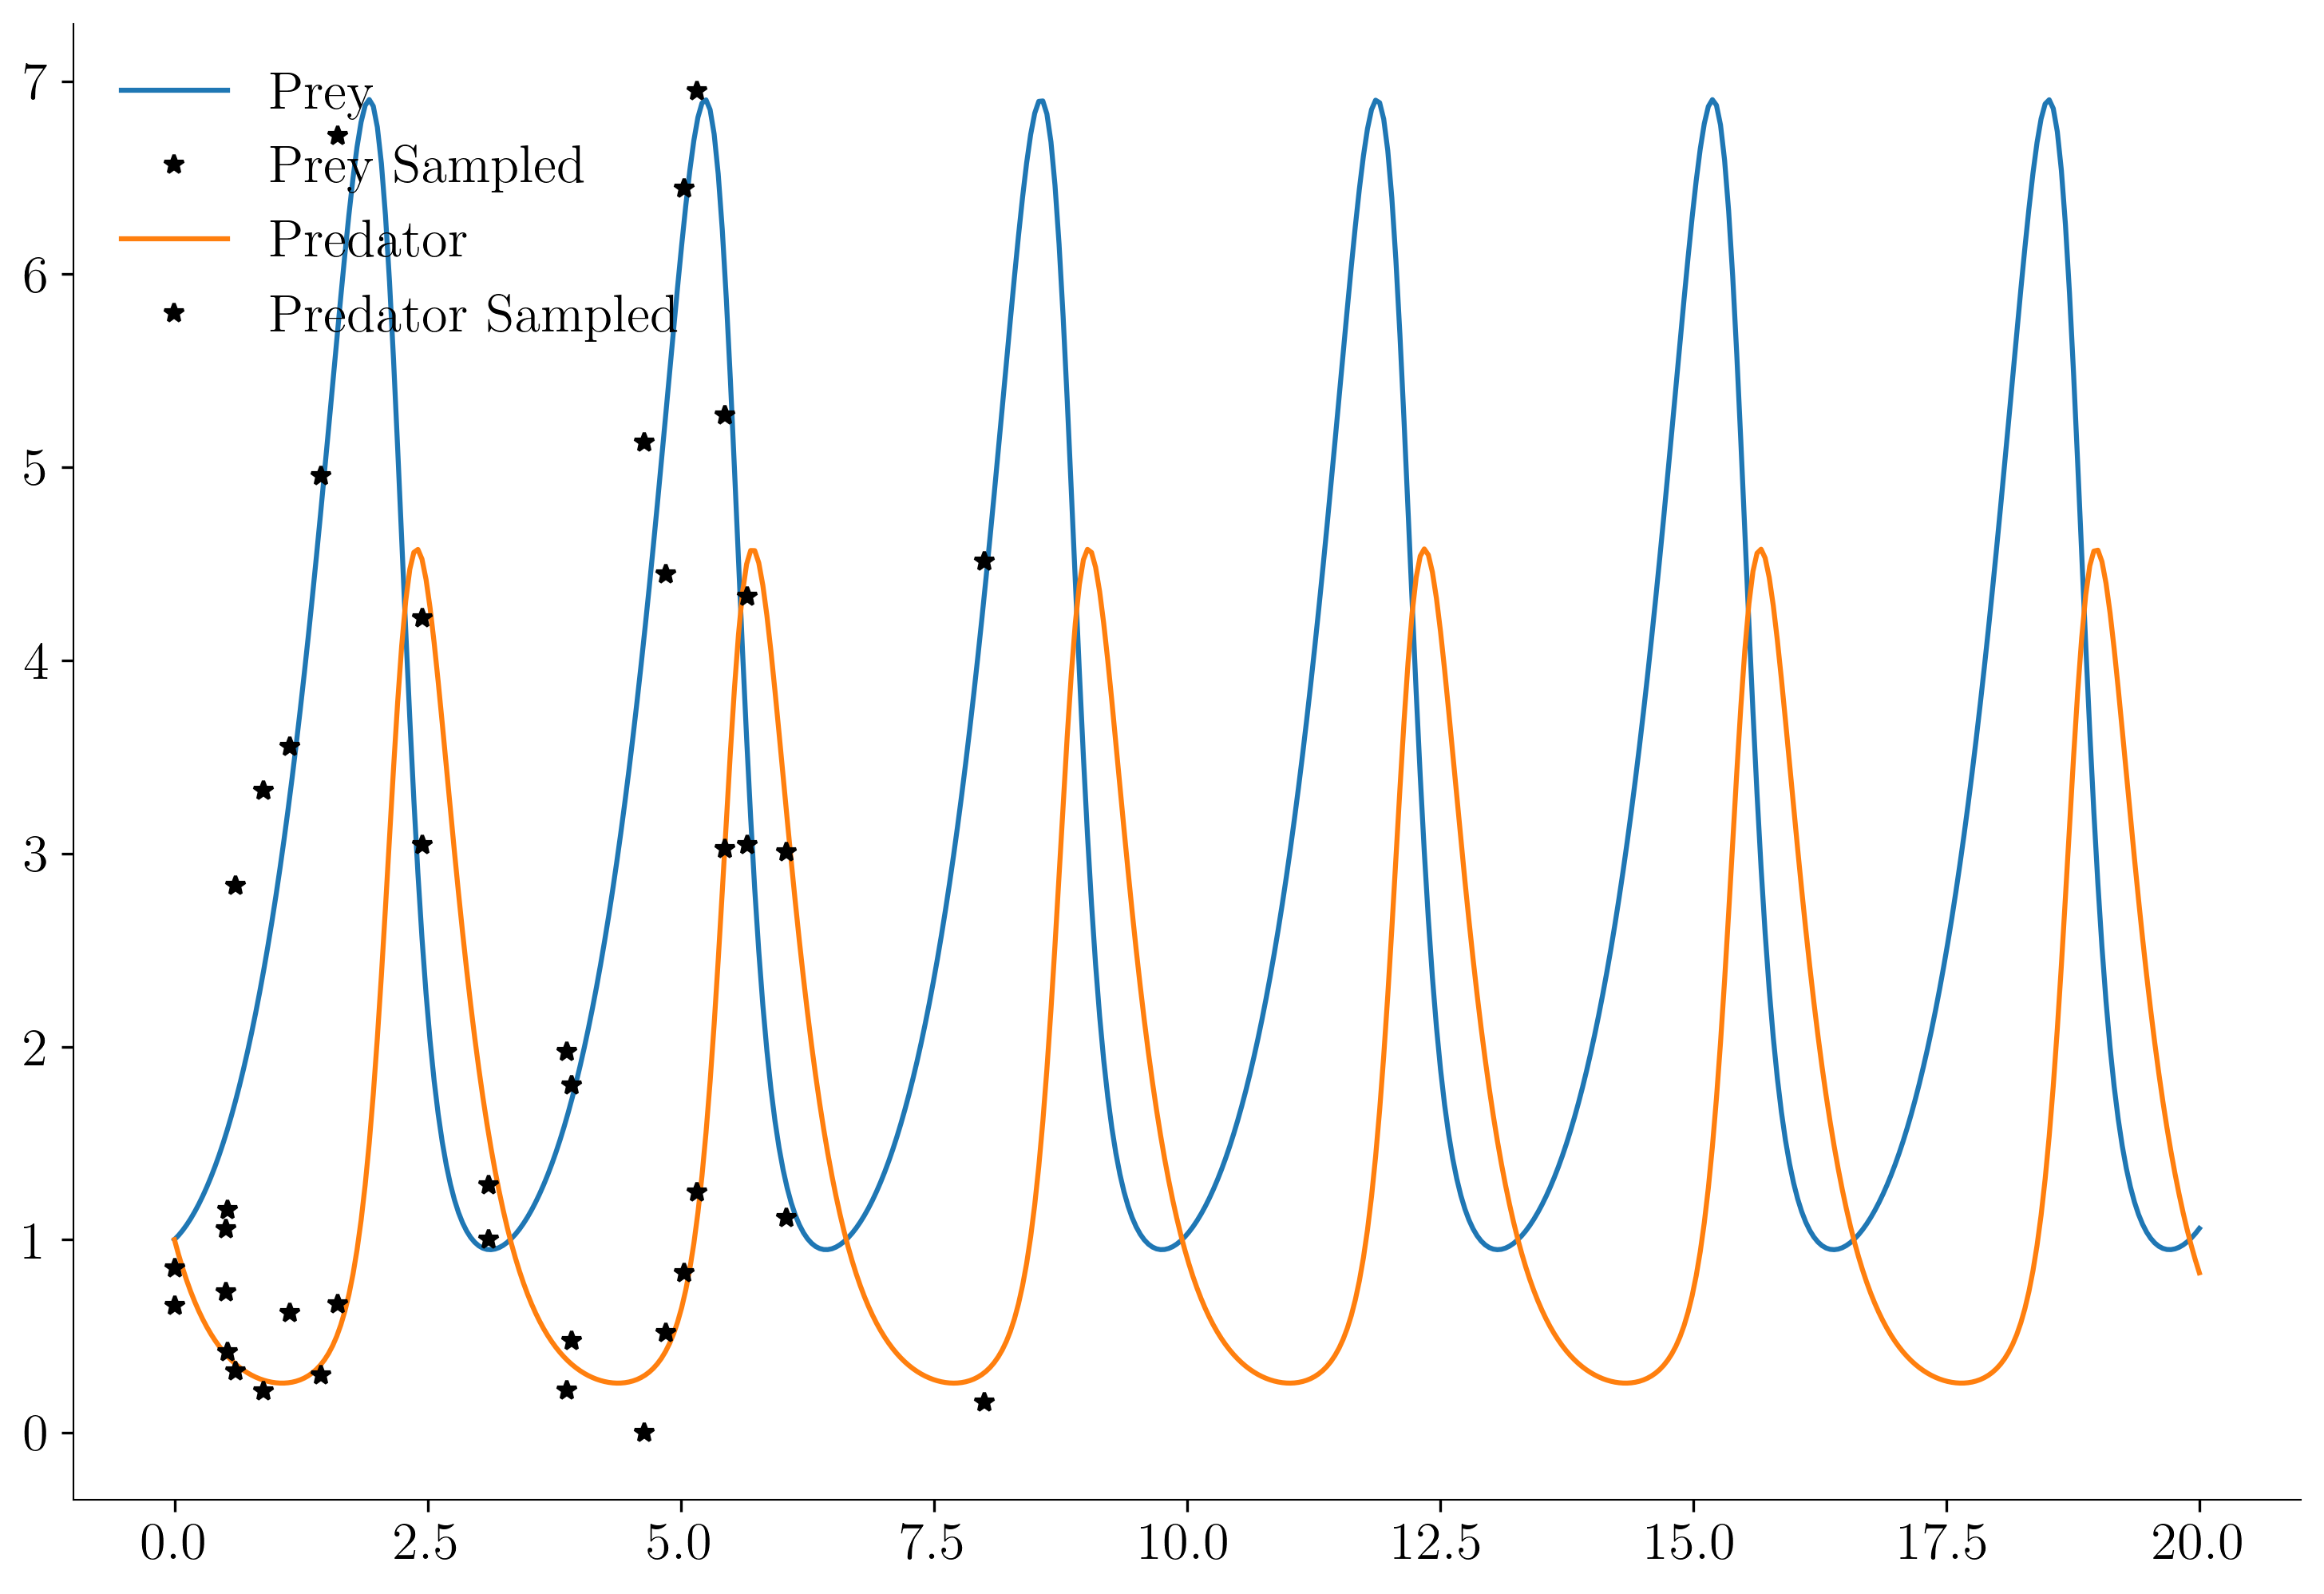

In [3]:
training_span = (0,8)
num_samples = 20
noiselevel = .2
num_regression_points = 300
# Step 1: Generate data ---------------------------------------------------
config.alpha, config.beta, config.gamma, config.delta = 1.5, 1, 3, 1
sampler = step1.TrajectorySampler(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    synced=True,
    integersonly=False,
    config=config,
)

(
    truthmodel,
    time_domain_prediction,
    true_states,
    time_domains_sampled,
    snapshots_sampled,
) = sampler.sample()
true_parameters = np.copy(truthmodel.parameters)

num_vars = len(true_states)
for i in range(num_vars):
    plt.plot(time_domain_prediction, true_states[i], label='Prey' if i == 0 else 'Predator')
    plt.plot(time_domains_sampled[i], snapshots_sampled[i], 'k*', label='Prey Sampled' if i == 0 else 'Predator Sampled')
plt.legend()
plt.show()

[100/100] NLL=4.280  ℓ=0.677  σ_f=1.222  σ=[1.0700176974642324, 0.5409190232830853]
Fitted hyperparameters: {'lengthscale': 0.6774077415466309, 'outputscale': 1.2223707437515259, 'sigma': [1.0700176974642324, 0.5409190232830853]}
torch.Size([20, 20]) torch.Size([20, 100])
torch.Size([20, 100])
Prediction shape: (100, 2)
First 5 predictions for output 1: [0.52229697 0.6374328  0.7722268  0.9278236  1.1047852 ]
First 5 predictions for output 2: [0.69470555 0.6934513  0.6820376  0.6605176  0.6293013 ]


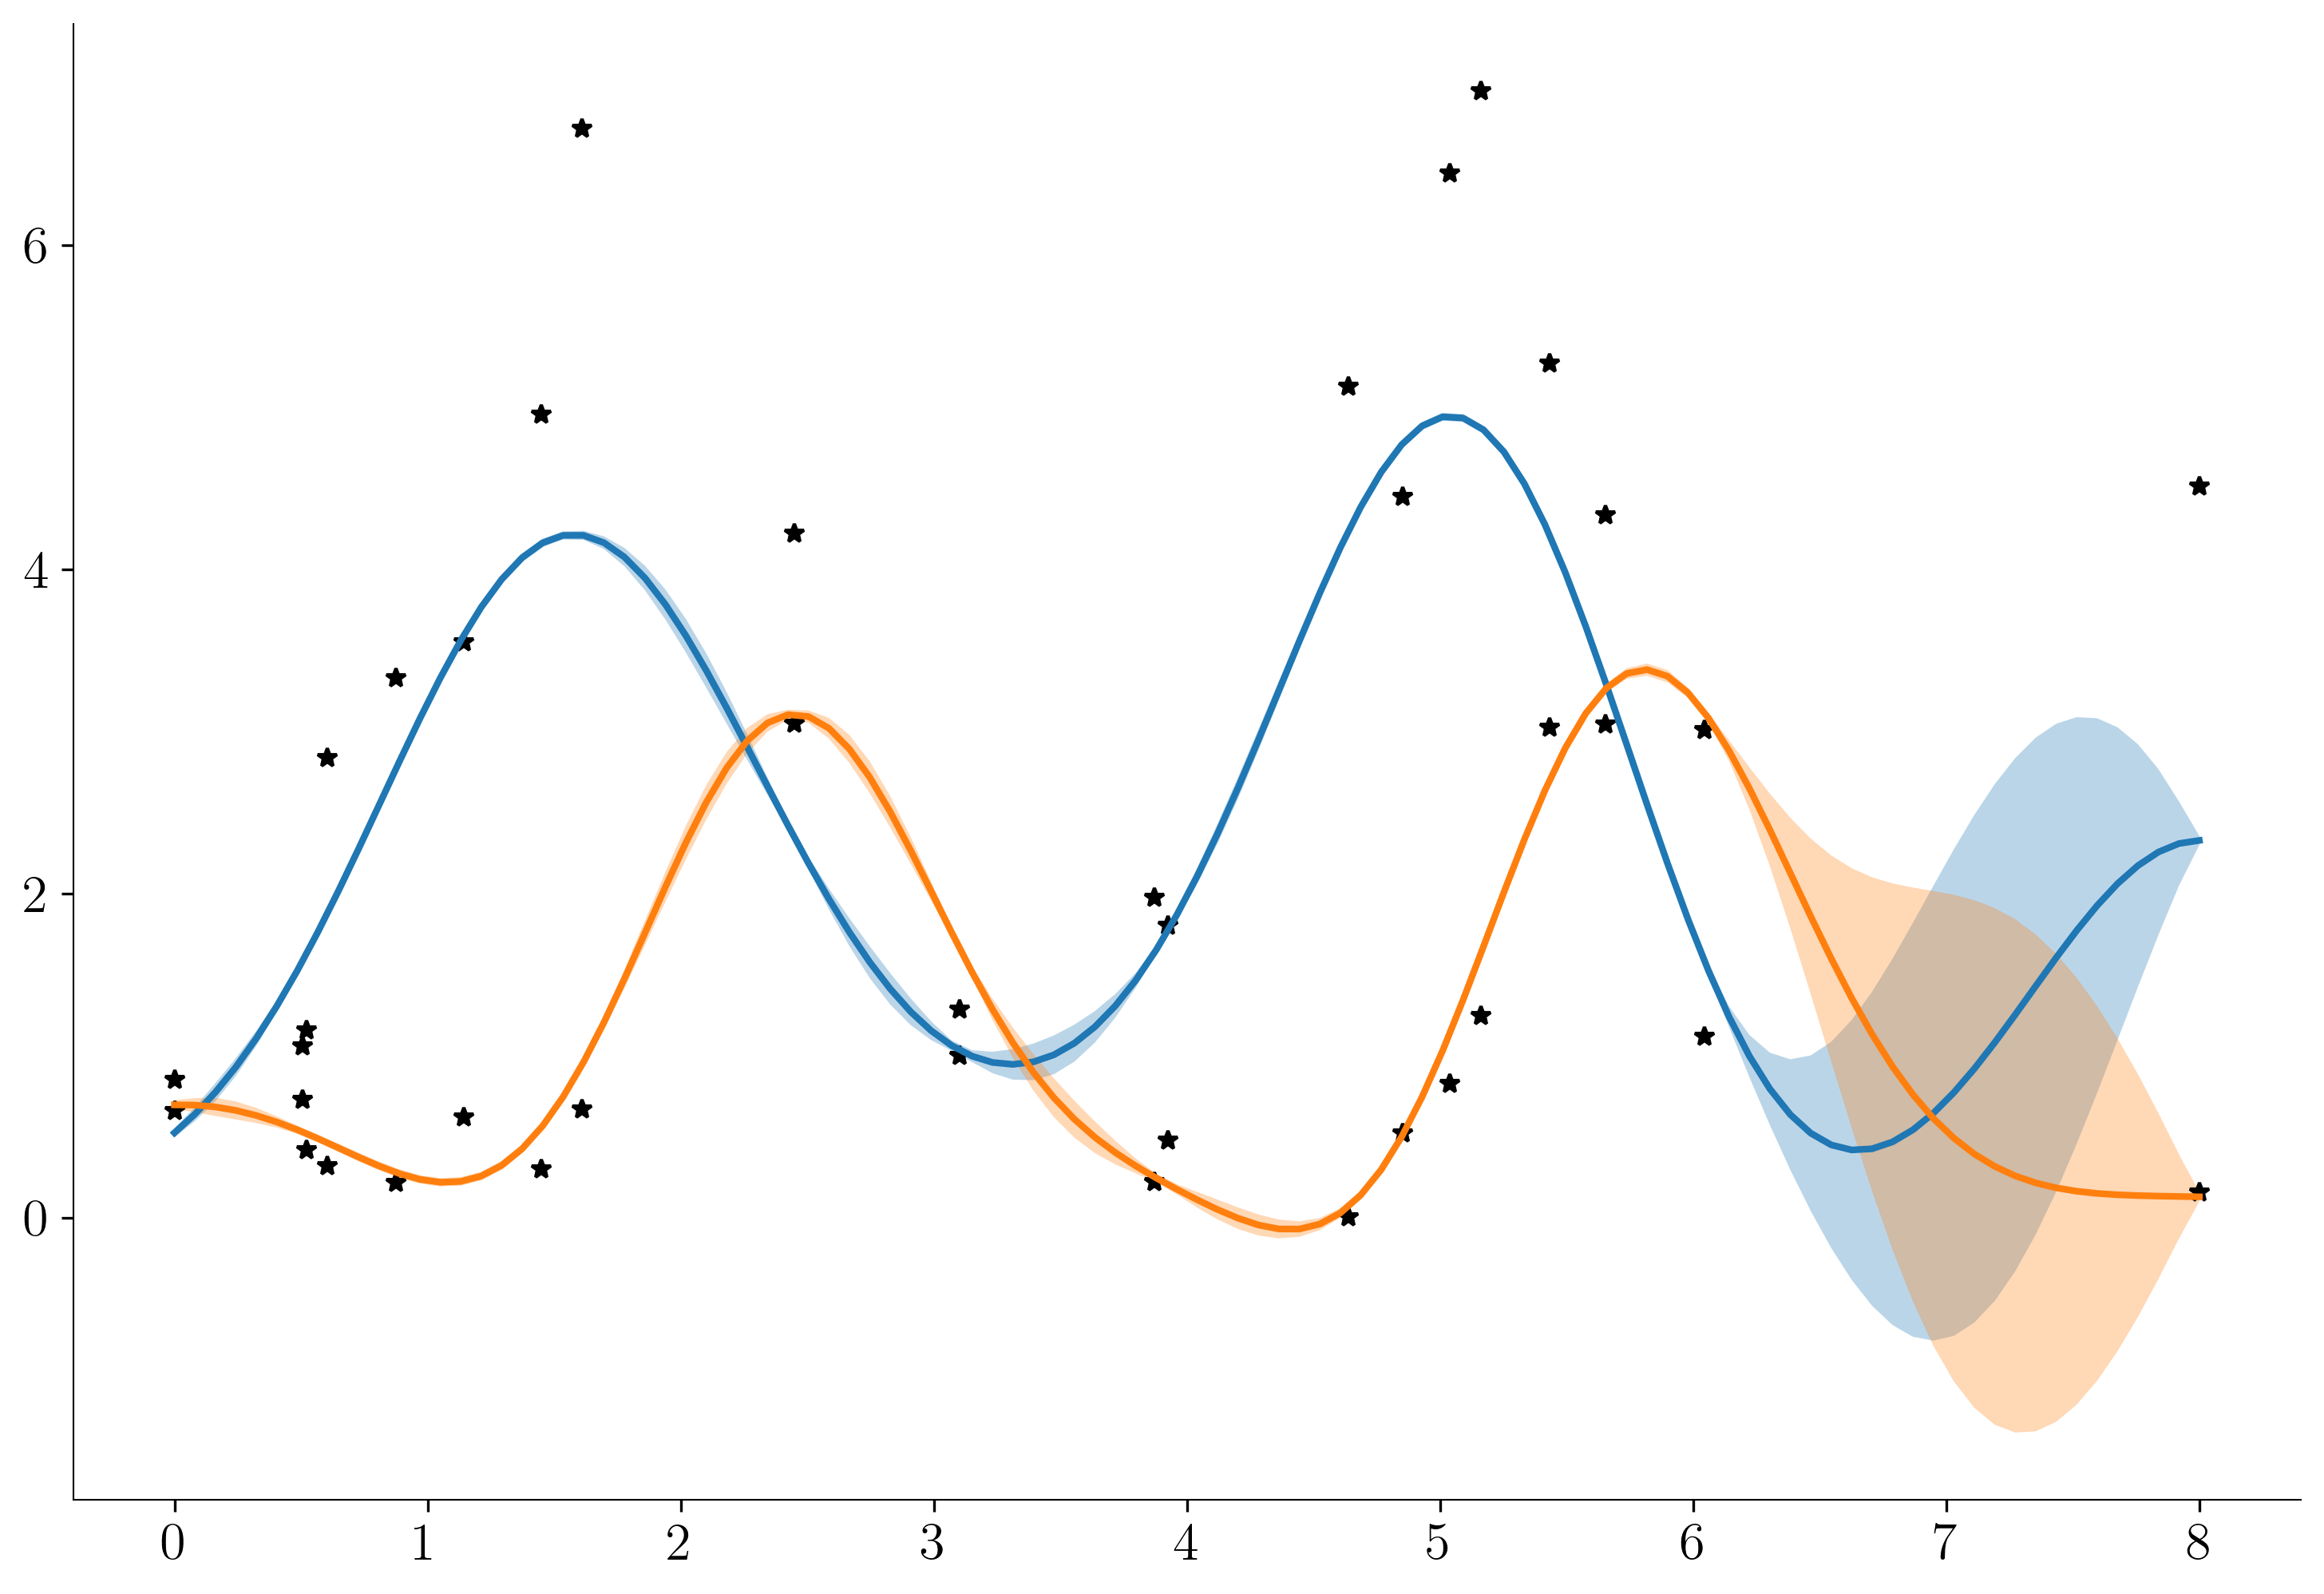

In [4]:
import torch
import gpytorch
import numpy as np
from torch.optim import Adam


import torch, gpytorch, numpy as np
from torch.optim import Adam


class _SharedRBF(gpytorch.kernels.ScaleKernel):
    """
    A tiny helper that lets us physically share one kernel object across all
    outputs – so there is only ONE set of hyper-parameters to optimise.
    """
    def __init__(self, base_kernel=None):
        if base_kernel is None:
            base_kernel = gpytorch.kernels.RBFKernel()
        super().__init__(base_kernel=base_kernel)


class RBFGPModel(gpytorch.models.ExactGP):
    """Scalar-output GP with a *shared* kernel object passed in."""
    def __init__(self, train_x, train_y, likelihood, shared_kernel):
        super().__init__(train_x, train_y, likelihood)
        self.train_x = train_x
        self.train_y = train_y
        # self.mean_module   = gpytorch.means.ConstantMean()
        self.mean_module   = gpytorch.means.ZeroMean()
        self.covar_module  = shared_kernel    # << one kernel, many models

    def forward(self, x):
        return gpytorch.distributions.MultivariateNormal(
            self.mean_module(x), self.covar_module(x)
        )


class MultiOutputRBFGP:
    """
    Same public API as before, but now:
      – truly shared kernel hyper-parameters,
      – latent posterior returned by predict(),
      – exact covariance (fast_pred_var disabled).
    """
    def __init__(self, nugget=1e-4):
        self.nugget        = nugget
        self.models        = []
        self.likelihoods   = []
        self._shared_kern  = _SharedRBF()        # ONE kernel instance
        self.is_fitted     = False

    # --------------------------------------------------------------------- #
    #                               FITTING                                 #
    # --------------------------------------------------------------------- #
    def fit(self, time_train, y_train, lr=0.01, iters=1_000):
        if y_train.ndim == 1:
            y_train = y_train[:, None]

        t  = torch.as_tensor(time_train, dtype=torch.float32)
        y  = torch.as_tensor(y_train , dtype=torch.float32)
        m  = y.shape[1]                       # number of outputs

        self.models, self.likelihoods = [], []

        for j in range(m):
            # independent noise per output (matches σ per trajectory)
            lik = gpytorch.likelihoods.GaussianLikelihood(
                       noise_constraint=gpytorch.constraints.GreaterThan(1e-4))
            mod = RBFGPModel(t, y[:, j], lik, self._shared_kern)
            self.likelihoods.append(lik)
            self.models.append(mod)

        # only optimise: shared kernel params + all likelihood noises
        params = list(self._shared_kern.parameters())
        for lik in self.likelihoods:
            params += list(lik.parameters())
        opt = Adam(params, lr=lr)

        mll = gpytorch.mlls.ExactMarginalLogLikelihood

        for i in range(iters):
            opt.zero_grad()
            loss = 0.0
            for mod, lik, col in zip(self.models, self.likelihoods, y.T):
                output = mod(t)
                loss  += -mll(lik, mod)(output, col)
            loss.backward()
            opt.step()

            if (i + 1) % 100 == 0:
                ls   = self._shared_kern.base_kernel.lengthscale.item()
                os   = self._shared_kern.outputscale.item()
                sigs = [l.noise.item()**0.5 for l in self.likelihoods]
                print(f"[{i+1}/{iters}] NLL={loss.item():.3f}  "
                      f"ℓ={ls:.3f}  σ_f={os:.3f}  σ={sigs}")

        self.is_fitted = True
        return dict(lengthscale = self._shared_kern.base_kernel.lengthscale.item(),
                    outputscale = self._shared_kern.outputscale.item(),
                    sigma       = [l.noise.item()**0.5 for l in self.likelihoods])

    # --------------------------------------------------------------------- #
    #                              PREDICT                                  #
    # --------------------------------------------------------------------- #
    def predict(self, time_test, return_cov=False):
        """
        Returns the latent-function posterior  (mean,  K_{**} - K_*ᵀ K^{-1} K_*).
        """
        assert self.is_fitted, "call .fit() first"
        tx  = torch.as_tensor(time_test, dtype=torch.float32)

        means, covs = [], []
        with torch.no_grad(), gpytorch.settings.fast_pred_var(False):
            for mod in self.models:
                mod.eval()
                dist = mod(tx)            # <-- latent, no likelihood
                means.append(dist.mean.numpy())
                # if return_cov:
                #     covs.append(dist.covariance_matrix.numpy())

        mu_star = np.column_stack(means)
        if return_cov:
            with torch.no_grad():
                # Compute the cov using the trick in wenk19
                time_train = self.models[0].train_x
                K = self.models[0].covar_module(time_train,time_train).evaluate() + torch.eye(time_train.shape[0])*self.nugget # Train train covar
                # train test covar 
                K_star = self.models[0].covar_module(time_train,tx).evaluate()
                # Test, test covar
                K_star_star = self.models[0].covar_module(tx,tx).evaluate()+ torch.eye(tx.shape[0])*self.nugget
            L = torch.linalg.cholesky(K)
            print(L.shape, K_star.shape)
            v = torch.linalg.solve(L, K_star)
            print(v.shape)
            # print((v.T @ v).shape)
            cov_star = K_star_star - (v.T @ v)
            return mu_star, cov_star.numpy()
        return mu_star

np.random.seed(0)

# Create and fit the model
gp = MultiOutputRBFGP(nugget=1e-4)
time_train = time_domains_sampled[0]
y_train = np.array([snapshots_sampled[0], snapshots_sampled[1]]).T
hyperparams = gp.fit(time_train, y_train, lr=0.01, iters=100)
print("Fitted hyperparameters:", hyperparams)

# Make predictions
time_test = np.linspace(0, 8, 100)
mu_star, cov_star = gp.predict( time_test, return_cov=True)
std = np.sqrt(np.diag(cov_star))

# Print prediction shape
print("Prediction shape:", mu_star.shape)
print("First 5 predictions for output 1:", mu_star[:5, 0])
print("First 5 predictions for output 2:", mu_star[:5, 1])

import matplotlib.pyplot as plt
plt.plot(time_train, y_train, 'k*', lw=2, )
plt.plot(time_test, mu_star, lw=2)

# 3) ±2σ uncertainty band (≈95% CI)
plt.fill_between(
    time_test,
    mu_star[:,0] - 2*std,
    mu_star[:,0] + 2*std,
    alpha=0.3,
    label='95% confidence interval'
)
# 3) ±2σ uncertainty band (≈95% CI)
plt.fill_between(
    time_test,
    mu_star[:,1] - 2*std,
    mu_star[:,1] + 2*std,
    alpha=0.3,
    label='95% confidence interval'
)